In [ ]:
import os
import re
import sys
import collections
import argparse
import itertools
import matplotlib
import glob
import math
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp_sparse
import scanpy as sc 
import scanpy.external as sce
from cnmf import cNMF
from scipy.stats import hypergeom
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
from scipy import sparse, io
import scipy.cluster.hierarchy as sch
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import pickle
import seaborn as sns
import gseapy as gp
from gseapy import Msigdb
import requests
from matplotlib.colors import LinearSegmentedColormap
import scanpy as ad
import pandas as pd
from tqdm import tqdm

In [ ]:
output_directory = '/output_directory'
run_name = 'Neuron_Prod1_cNMF_run'
cnmf_obj = cNMF(output_dir=output_directory, name=run_name)
K_values = [50,100,200,250,500]
density_threshold = 0.1

In [ ]:
def load_results(self, K, density_threshold, n_top_genes=300):
        scorefn = self.paths['gene_spectra_score__txt'] % (K, str(density_threshold).replace('.', '_'))
        tpmfn = self.paths['gene_spectra_tpm__txt'] % (K, str(density_threshold).replace('.', '_'))
        usagefn = self.paths['consensus_usages__txt'] % (K, str(density_threshold).replace('.', '_'))
        spectra_scores = pd.read_csv(scorefn, sep='\t', index_col=0).T
        spectra_tpm = pd.read_csv(tpmfn, sep='\t', index_col=0).T

        usage = pd.read_csv(usagefn, sep='\t', index_col=0)
        usage = usage.div(usage.sum(axis=1), axis=0)

        try:
            usage.columns = [int(x) for x in usage.columns]
        except:
            print('Usage matrix columns include non integer values')

        top_genes = []
        for gep in spectra_scores.columns:
            top_genes.append(list(spectra_scores.sort_values(by=gep, ascending=False).index[:n_top_genes]))

        top_genes = pd.DataFrame(top_genes, index=spectra_scores.columns).T
        return(usage, spectra_scores, spectra_tpm, top_genes)

In [13]:
cNMF_output_dict_all_Ks = {}

# Iterate over each K value
for K in K_values:
    usage_norm, gep_scores, gep_tpm, topgenes = load_results(cnmf_obj, K=K, density_threshold=density_threshold)
    
    # Rename the columns of usage_norm
    usage_norm.columns = ['Usage_%d' % i for i in usage_norm.columns]
    
    # Store the results in the dictionary with dynamic keys
    cNMF_output_dict_all_Ks[f'usage_norm_k_{K}'] = usage_norm
    cNMF_output_dict_all_Ks[f'gep_scores_k_{K}'] = gep_scores
    cNMF_output_dict_all_Ks[f'gep_tpm_k_{K}'] = gep_tpm
    cNMF_output_dict_all_Ks[f'topgenes_k_{K}'] = topgenes

In [14]:
usage, spectra_scores, spectra_tpm, top_genes = cnmf_obj.load_results(K=200, density_threshold=0.1)

In [ ]:
adata = ad.read_h5ad("development_dataset/velmeshev_snRNA_seq.h5ad")

In [ ]:
#Score programs
programs = spectra_scores.columns 
print(f"Scoring {len(programs)} programs across {adata.n_obs} cells...")

for program in tqdm(programs, desc="Calculating Program Scores"):
    # Get top 300 genes for this specific program
    top_genes = spectra_scores[program].sort_values(ascending=False).head(300).index.tolist()
    
    # Filter for genes that exist in the brain atlas
    valid_genes = [g for g in top_genes if g in adata.var_names]
    
    if len(valid_genes) > 5:
        # Compute the score
        # score_genes adds a column to adata.obs named after 'score_name'
        sc.tl.score_genes(adata, 
                         gene_list=valid_genes, 
                         score_name=f"prog_{program}", use_raw=False)
    else:
        print(f"Skipping {program}: too few overlapping genes found.")

# The scores are now stored in adata.obs
print("Done! Scores are stored in adata.obs")

Scoring 200 programs across 3591 cells...


Calculating Program Scores:  49%|███████████████████████████████████████████████████████▎                                                         | 98/200 [00:20<00:20,  4.91it/s]/project/Neuroinformatics_Core/Chahrour_lab/s217793/IGVF/production1/cnmf_env/lib/python3.10/site-packages/scanpy/tools/_score_genes.py:165: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[score_name] = pd.Series(
Calculating Program Scores:  50%|███████████████████████████████████████████████████████▉                                                         | 99/200 [00:20<00:20,  4.90it/s]/project/Neuroinformatics_Core/Chahrour_lab/s217793/IGVF/production1/cnmf_env/lib/python3.10/site-packages/scanpy/tools/_score_genes.py:165: PerformanceWarning: DataFrame is highly fragme

Done! Scores are stored in adata.obs


In [ ]:
meta = pd.read_csv('velmeshev_meta.tsv', sep='\t', index_col=0)
adata.obs = adata.obs.join(meta)

/tmp/ipykernel_1126512/2482678984.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv('development_dataset/meta.tsv', sep='\t', index_col=0)


In [ ]:
# Define the mapping dictionary
adata.obs['Individual'] = adata.obs['Individual'].astype(str)
age_map = {
    '2nd trimester': 'Fetal',
    '3rd trimester': 'Fetal',
    '0-1 years': 'Early postnatal',
    '1-2 years': 'Early postnatal',
    '2-4 years': 'Early postnatal',
    '4-10 years': 'Late postnatal',
    '10-20 years': 'Late postnatal',
    'Adult': 'Adult'
}
adata.obs['grouped_age'] = adata.obs['Age_Range'].map(age_map)
age_order = ['Fetal', 'Early postnatal', 'Late postnatal', 'Adult']
adata.obs['grouped_age'] = pd.Categorical(adata.obs['grouped_age'], categories=age_order, ordered=True)

In [ ]:
sc.pl.umap(adata, color="prog_1", cmap='magma')

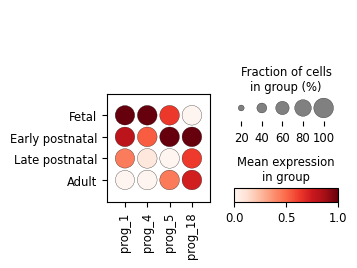

In [32]:
my_programs_selected = ['prog_1','prog_4', 'prog_5', 'prog_18']
sc.pl.dotplot(adata, var_names=my_programs_selected, groupby='grouped_age', 
              standard_scale='var', color_map='Reds')

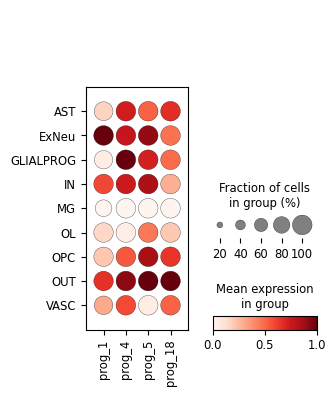

In [34]:
my_programs_selected = ['prog_1','prog_4', 'prog_5', 'prog_18']
sc.pl.dotplot(adata, var_names=my_programs_selected, groupby='Lineage', 
              standard_scale='var', color_map='Reds')